<a href="https://colab.research.google.com/github/yaokarenn/CIFAR-10/blob/main/cifar10_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step - accuracy: 0.7263 - loss: 0.7963 - val_accuracy: 0.8640 - val_loss: 0.3826
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.8716 - loss: 0.3636 - val_accuracy: 0.8838 - val_loss: 0.3208
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 101ms/step - accuracy: 0.8879 - loss: 0.3105 - val_accuracy: 0.8912 - val_loss: 0.2963
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.8963 - loss: 0.2829 - val_accuracy: 0.8945 - val_loss: 0.2869
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9078 - loss: 0.2505 - val_accuracy: 0.9032 - val_loss: 0.2605
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.9153 - loss: 0.2316 - val_accuracy: 0.9040 - val_loss: 0.2641
Epoch 7/10
422/422 ━━━━━━━

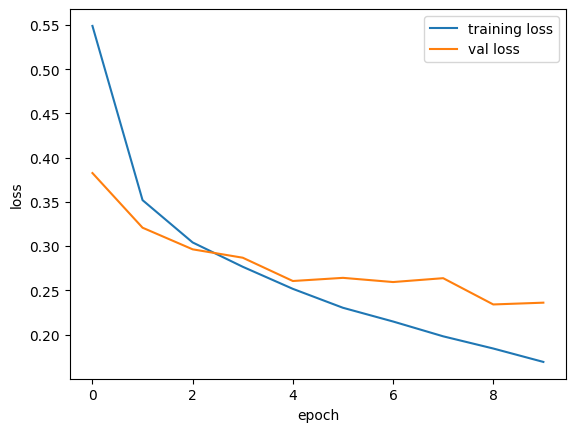

Best training-loss epoch: 10
Best validation-loss epoch: 9


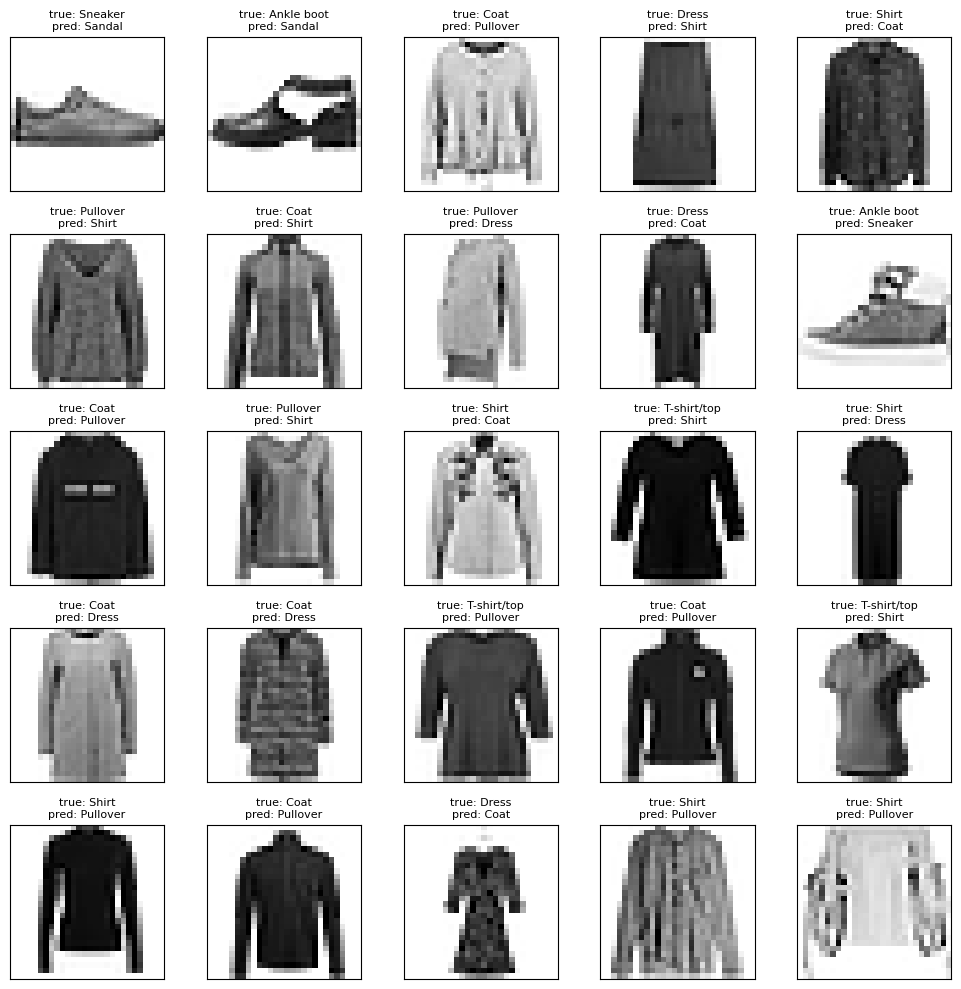

Sneaker class → TP:961, TN:8962, FP:38, FN:39
Accuracy:0.992, Sensitivity:0.961, Precision:0.962


In [ ]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist

# --- 1) Load & preprocess data ---
# Dataset: Fashion-MNIST (28x28 grayscale)
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Scale to [0, 1] and add channel dimension
train_images = (train_images / 255.0).astype("float32")[..., np.newaxis]  # (N, 28, 28, 1)
test_images  = (test_images  / 255.0).astype("float32")[..., np.newaxis]

# One-hot labels (since we'll compile with categorical_crossentropy)
train_labels_one_hot = to_categorical(train_labels, num_classes=10)
test_labels_one_hot  = to_categorical(test_labels,  num_classes=10)

# For your helper variables
train_data = (train_images, train_labels_one_hot)
test_data  = (test_images,  test_labels_one_hot)

# Class names for pretty titles
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# --- 2) Build a simple CNN model ---
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# --- 3) Train ---
history = model.fit(
    train_images, train_labels_one_hot,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# --- 4) Plot training loss ---
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

# Find epoch with the least training loss (and validation loss)
best_train_epoch = int(np.argmin(history.history["loss"])) + 1
best_val_epoch   = int(np.argmin(history.history["val_loss"])) + 1
print(f"Best training-loss epoch: {best_train_epoch}")
print(f"Best validation-loss epoch: {best_val_epoch}")

# --- 5) Helper: plot incorrect predictions ---
def plot_incorrect_evaluations(model, test_data, class_names, max_to_show=25):
    test_images, test_labels_one_hot = test_data
    # Predict probabilities -> predicted class ids
    preds = model.predict(test_images, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(test_labels_one_hot, axis=1)

    incorrect_indices = np.where(y_pred != y_true)[0]
    n = min(max_to_show, len(incorrect_indices))
    if n == 0:
        print("No incorrect predictions to show!")
        return

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(incorrect_indices[:n]):
        plt.subplot(5, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(test_images[idx].squeeze(), cmap=plt.cm.binary)
        plt.title(f"true: {class_names[y_true[idx]]}\npred: {class_names[y_pred[idx]]}", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_incorrect_evaluations(model, test_data, class_names)

# --- 6) (Optional) Simple metrics using one-hot labels ---
def metrics_from_onehot(y_true_onehot, y_pred_ids, positive_class=0):
    """
    Computes TP, TN, FP, FN for a chosen positive_class (0..9).
    Useful if you want binary-style metrics for one class at a time.
    """
    y_true = np.argmax(y_true_onehot, axis=1)
    y_hat = (y_pred_ids == positive_class).astype(int)
    y_pos = (y_true == positive_class).astype(int)

    TP = np.sum((y_pos == 1) & (y_hat == 1))
    TN = np.sum((y_pos == 0) & (y_hat == 0))
    FP = np.sum((y_pos == 0) & (y_hat == 1))
    FN = np.sum((y_pos == 1) & (y_hat == 0))
    return TP, TN, FP, FN

# Example: compute binary metrics for class "Sneaker" (index 7)
pred_probs = model.predict(test_images, verbose=0)
y_pred_ids = np.argmax(pred_probs, axis=1)
TP, TN, FP, FN = metrics_from_onehot(test_labels_one_hot, y_pred_ids, positive_class=7)
accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN) if (TP + FN) else 0.0
precision  = TP / (TP + FP) if (TP + FP) else 0.0
print(f"Sneaker class → TP:{TP}, TN:{TN}, FP:{FP}, FN:{FN}")
print(f"Accuracy:{accuracy:.3f}, Sensitivity:{sensitivity:.3f}, Precision:{precision:.3f}")
